## Premature Mortality < 65 (Anteil Todesfälle unter 65)
Ziel dieses Abschnitts ist es für jedes Land und jedes Jahr den Anteil der Todesfälle zu berechnen, dievor dem 65. Lebenensjahr aufgetreten sind.


In [105]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr, spearmanr
from scipy.stats import ttest_ind
from scipy.stats import kruskal
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm
import plotly.express as px
import scipy.stats as stats
from mpl_toolkits.mplot3d import Axes3D

In [2]:
df = pd.read_csv("Data_Files/base_data104_with_lookup.csv")

### Todesfälle unter 65 berechnen
Für jede einzelne Row summieren wir alle Todesfälle in den Altersklassen 0 bis 64. Da manche Länder pro Jahr mehrere Einträge haben aggregieren wir die Daten nach Country und Year. Für jedes Jahr berechnen wir deaths_u65 und deaths_total. Damit können wir dann p_u65 berechnen. 

In [3]:
age_u65 = ["Deaths at age 0","Deaths at age 1","Deaths at age 2","Deaths at age 3","Deaths at age 4","Deaths at age 5-9","Deaths at age 10-14","Deaths at age 15-19","Deaths at age 20-24","Deaths at age 25-29","Deaths at age 30-34","Deaths at age 35-39","Deaths at age 40-44","Deaths at age 45-49","Deaths at age 50-54","Deaths at age 55-59","Deaths at age 60-64"]

#Summe der Todesfälle unter 65 Jahren pro Zeile
df["deaths_u65_row"] = df[age_u65].sum(axis=1)

#Gruppieren nach Land und Jahr, Summe der Todesfälle unter 65 Jahren und aller Todesfälle
grouped = df.groupby(["Country", "Year"]).agg(deaths_u65_total=("deaths_u65_row", "sum"), deaths_all_total=("Deaths at all ages", "sum"),).reset_index()

#Anteil der Todesfälle unter 65 Jahren berechnen
grouped["p_u65"] = grouped["deaths_u65_total"] / grouped["deaths_all_total"]
grouped = grouped.dropna(subset=["p_u65"])
print(grouped.head())

    Country  Year  deaths_u65_total  deaths_all_total     p_u65
0  Anguilla  2000              26.0               144  0.180556
1  Anguilla  2001              28.0               104  0.269231
2  Anguilla  2002              42.0               114  0.368421
3  Anguilla  2003              50.0               140  0.357143
4  Anguilla  2004              22.0                96  0.229167


## Analyse des Referenzjahrs 2017
Nachdem wir überprüft habe, in welchen Jahren die meisten Länder Daten lieferten, fokussieren wir und hier auf das Jahr 2017, da diese eine gute Daten Abdeckung hat. 

Das Histogramm zeigt, wie häufig verschiedene p-Werte unter den Ländern vorkommen
Die KDE-Kurve gibt eine Schätzung der der Wahrscheinlichkeitsdichte

Wir wollen dabei erkennen, wie die Verteilung ist, ob es Ausreisser gibt und in welchem Bereich sich die meisten Länder bewegen.

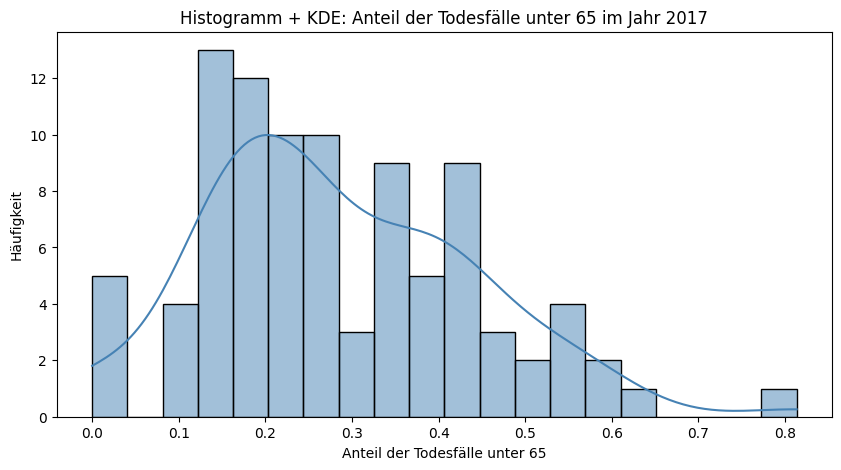

In [37]:
df_2017 = grouped[grouped["Year"] == 2017].dropna(subset=["p_u65"])

plt.figure(figsize=(10, 5))
sns.histplot(df_2017["p_u65"], bins=20, kde=True, color="steelblue")

plt.title("Histogramm + KDE: Anteil der Todesfälle unter 65 im Jahr 2017")
plt.xlabel("Anteil der Todesfälle unter 65")
plt.ylabel("Häufigkeit")
plt.show()

Das Histogramm zeigt eine klare rechtsschiefe Verteilung. Die meisten Länder liegen im Bereich 0.15 bis 0.30. Es gibt einen langen rechten Schwanz. Einige Länder haben deutlich höhere p-Werte und daher einen höheren Anteil an Todesfällen unter 65. Es gibt auch einige sehr niedrige Werte. Bei den Werte nahe bei 0, handelt es sich möglicherweise um Datenfehler. 
Die KDE Kurve bestätigt ein Peak um etwa 0.2 und dann gibt es ein langsames abfallen.
Insgeseamt zeigt die Verteilung eine starke Heterogenität zwischen den Ländern.

### ECDF von p_u65 im Jahr 2016
Um die Verteilung von p_u65 genauer zu beschreiben, verwenden wir zusätzlich ein ECDF

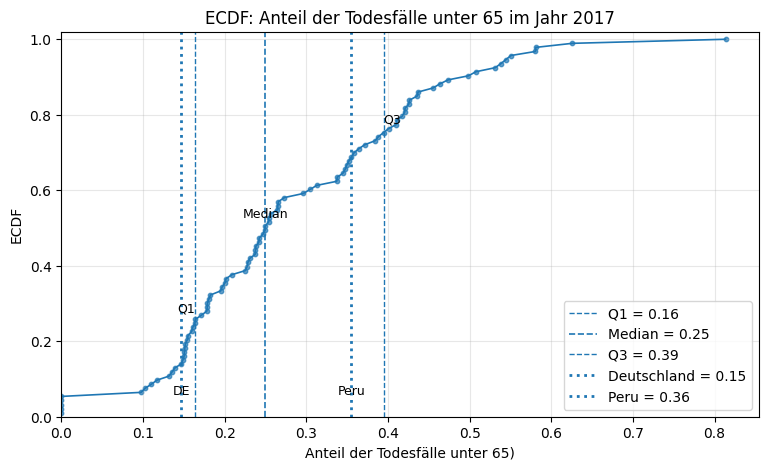

In [41]:
#Werte sortieren
x = np.sort(df_2017["p_u65"].dropna())
#ECDF Werte berechnen
y = np.arange(1, len(x) + 1) / len(x)

# Quantile berechnen
q1_2017 = np.percentile(x, 25)
median_2017 = np.percentile(x, 50)
q3_2017 = np.percentile(x, 75)

plt.figure(figsize=(9, 5))

# ECDF-Linie + Punkte
plt.plot(x, y, linestyle="-", linewidth=1.2, color="#1f77b4")
plt.scatter(x, y, s=10, color="#1f77b4", alpha=0.7)

#Linien bei den Quantilen
plt.axvline(q1_2017, linestyle="--", linewidth=1, label=f"Q1 = {q1_2017:.2f}")
plt.axvline(median_2017, linestyle="--", linewidth=1.2, label=f"Median = {median_2017:.2f}")
plt.axvline(q3_2017, linestyle="--", linewidth=1, label=f"Q3 = {q3_2017:.2f}")

#Quartile beschriften
plt.text(q1_2017, 0.27, "Q1", ha="right", va="bottom", fontsize=9)
plt.text(median_2017, 0.52, "Median", ha="center", va="bottom", fontsize=9)
plt.text(q3_2017, 0.77, "Q3", ha="left", va="bottom", fontsize=9)

#Achsenbeschriftungen und Titel
plt.xlabel("Anteil der Todesfälle unter 65)")
plt.ylabel("ECDF")
plt.title("ECDF: Anteil der Todesfälle unter 65 im Jahr 2017")

#Werte für Deutschland und Peru holen, um diese im Diagramm zu markieren
p_de = df_2017.loc[df_2017["Country"] == "Germany", "p_u65"].values[0]
p_pe = df_2017.loc[df_2017["Country"] == "Peru", "p_u65"].values[0]

#als vertikale Linien einzeichnen
plt.axvline(p_de, linestyle=":", linewidth=2, label=f"Deutschland = {p_de:.2f}")
plt.axvline(p_pe, linestyle=":", linewidth=2, label=f"Peru = {p_pe:.2f}")

# Text direkt ins Diagramm
plt.text(p_de, 0.05, "DE", ha="center", va="bottom", fontsize=9)
plt.text(p_pe, 0.05, "Peru", ha="center", va="bottom", fontsize=9)

#Layout
plt.xlim(0, x.max() * 1.05)
plt.ylim(0, 1.02)
plt.grid(alpha=0.3)
plt.legend(loc="lower right")
plt.show()


Der Median liegt bei etwa 0.25, das heisst in 50% der Länder beträgt der Anteil der Todesfälle unter 65 höchstens 25%
Das untere Quartil liegt bei 0.16, wodurch rund 25 % der Länder einen Anteil unter 16 % aufweisen.
Das obere Quartil liegt bei etwa 0.39, was bedeutet, dass 75 % der Länder einen Anteil unter 39 % haben.
Der Grossteil der Länder liegt im Bereich zwischen Q1 und Q3.
Insgesmat bestätigt die ECDF eine ungleiche Verteilung zwischen den Ländern.


### Tukey Fences für das Jahr 2017

In [42]:
#Quartile und IQR berechnen
q1 = df_2017["p_u65"].quantile(0.25)
q3 = df_2017["p_u65"].quantile(0.75)
iqr = q3 - q1

#Untere und obere Tukey Grenze
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

#Werte ausgeben
print(f"Q1 = {q1:.3f}, Q3 = {q3:.3f}, IQR = {iqr:.3f}")
print(f"Lower fence = {lower_fence:.3f}, Upper fence = {upper_fence:.3f}")

#Ausreisser markieren
df_2017["tukey_flag"] = "ok"
df_2017.loc[df_2017["p_u65"] < lower_fence, "tukey_flag"] = "low_outlier"
df_2017.loc[df_2017["p_u65"] > upper_fence, "tukey_flag"] = "high_outlier"

#Ausreisser anzeigen und sortieren
df_y_outliers = df_2017[df_2017["tukey_flag"] != "ok"]
df_y_outliers.sort_values("p_u65").head()

Q1 = 0.164, Q3 = 0.395, IQR = 0.230
Lower fence = -0.181, Upper fence = 0.740


,Country,Year,deaths_u65_total,deaths_all_total,p_u65,tukey_flag
1784,Solomon Islands,2017,680.0,836,0.813397,high_outlier


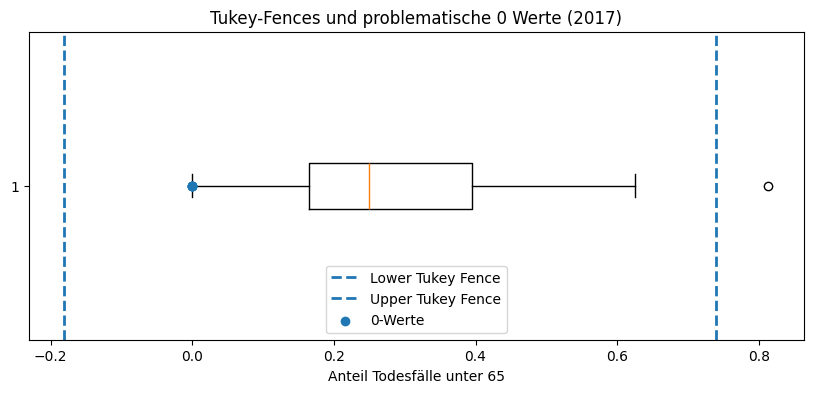

In [ ]:

x = df_2017["p_u65"].dropna()
plt.figure(figsize=(10, 4))

#Boxplot horizontal
plt.boxplot(x, vert=False)

#Tukey Grenzen einzeichnen
plt.axvline(lower_fence, linestyle="--", linewidth=2, label="Lower Tukey Fence")
plt.axvline(upper_fence, linestyle="--", linewidth=2, label="Upper Tukey Fence")

#0 Werte markieren
zero_values = x[x == 0]
y_jitter = np.random.normal(1, 0.02, size=len(zero_values))
plt.scatter(zero_values, np.ones(len(zero_values)), label="0-Werte", zorder=3)

plt.title("Tukey-Fences und problematische 0 Werte (2017)")
plt.xlabel("Anteil Todesfälle unter 65")
plt.legend()
plt.show()


### Löschen der 0-Werte
Ein Wert von 0 ist sehr unlogisch und es handelt sich daher mit Sicherheit um Datenfehler. Aus diesem Grund löschen wir diese aus dem Datensatz.

In [8]:
df_2017_clean = df_2017[(df_2017["p_u65"] > 0)].copy()


### Karte 2017
Wir erstellen eine Karte, welche die Anteile der Todesfälle im Jahr 2017 unter 65 zeigt.
Wir sehen, dass viele entwickelte Länder ein kleinerer Anteil der Todesfälle vor dem 65. Geburtstag haben. In Teilen Südamerikas und Zentralasien ist der Anteil deutlich höher. Ausserdem ist aufällig, dass zahlreiche Länder keine Daten meldeten, vor allem Länder in Afrika.

In [ ]:
df_2017_map = df_2017.copy()

fig = px.choropleth(
    df_2017_map,
    locations="Country",
    locationmode="country names",
    color="p_u65",
    color_continuous_scale="Reds",
    range_color=(df_2017_map["p_u65"].min(), df_2017_map["p_u65"].max()),
    title="Anteil Todesfälle unter 65 Jahren im Jahr 2017",
    labels={"p_u65": "Anteil < 65"}
)

fig.update_layout(geo=dict(showframe=False, showcoastlines=True),)
fig.write_html("karte_p_u65_2017.html")


C:\Users\nevio\AppData\Local\Temp\ipykernel_33028\662573063.py:3: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



### Einlesen der Worldbank Daten
Der Median-Age-Proxy wird als gewichteter Durchschnitt der drei Altersgruppen berechnet. Jede Altersgruppe wird durch ein typisches Alter repräsentiert und entsprechend ihrem Bevölkerungsanteil gewichtet. Der Proxy ist eine Vereinfachung zum vergleichen der Altersstruktur zwischen Ländern.

In [51]:
#Altersdaten einlesen der World Bank 
age_0_14_raw = pd.read_csv("Data_Files/API_SP.POP.0014.TO.ZS_DS2_en_csv_v2_253632.csv", skiprows=4)
age_15_64_raw = pd.read_csv("Data_Files/API_SP.POP.1564.TO.ZS_DS2_en_csv_v2_294218.csv", skiprows=4)
age_65_raw    = pd.read_csv("Data_Files/API_SP.POP.65UP.TO.ZS_DS2_en_csv_v2_8582.csv",   skiprows=4)

#Wir brauchen nur den Ländernamen und den Wert für 2017
age_0_14 = age_0_14_raw[["Country Name", "2017"]].rename(columns={"Country Name": "Country","2017": "pct_0_14"})

age_15_64 = age_15_64_raw[["Country Name", "2017"]].rename(columns={"Country Name": "Country","2017": "pct_15_64"})

age_65 = age_65_raw[["Country Name", "2017"]].rename(columns={"Country Name": "Country","2017": "pct_65plus"})

#Alle Altersgruppen zusammenführen
age_all = age_0_14.merge(age_15_64, on="Country", how="inner").merge(age_65,    on="Country", how="inner")

#Anäherung an das Medianalter berechnen
age_all["median_age_proxy"] = (7  * (age_all["pct_0_14"]   / 100) + 40 * (age_all["pct_15_64"]  / 100) +75 * (age_all["pct_65plus"] / 100))

print(age_all.head())


                       Country   pct_0_14  pct_15_64  pct_65plus  \
0                        Aruba  18.848393  68.434841   12.716766   
1  Africa Eastern and Southern  42.250079  54.675092    3.074828   
2                  Afghanistan  45.364605  52.275658    2.359737   
3   Africa Western and Central  43.700271  53.399389    2.900340   
4                       Angola  45.250826  52.063932    2.685242   

   median_age_proxy  
0         38.230898  
1         27.133664  
2         25.855588  
3         26.594030  
4         26.007062  


### Zusammenhang zwischen Alterstruktur und vorzeitiger Mortalität

               Country     p_u65  median_age_proxy
0  Antigua and Barbuda  0.364121         36.411914
1            Argentina  0.264715         35.846380
2              Armenia  0.265843         37.240351
3                Aruba  0.250000         38.230898
4            Australia  0.178107         39.168046


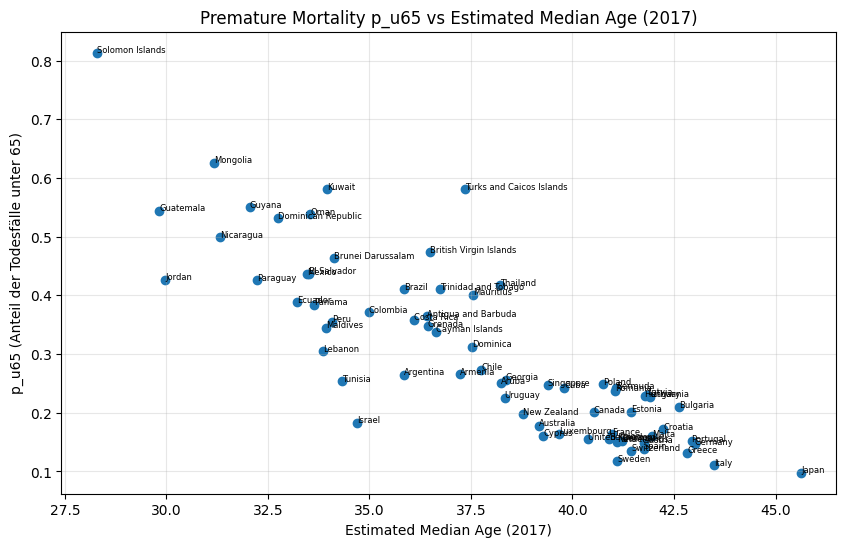

Pearson r (Median Age vs p_u65): -0.849, p-value: 0.00000


In [ ]:
# p_u65 mit Altersdaten mergen über Ländernamen
corr_age = df_2017_clean.merge(age_all, on="Country", how="inner")
print(corr_age[["Country", "p_u65", "median_age_proxy"]].head())

# Scatterplot Median Age vs p_u65
plt.figure(figsize=(10, 6))
plt.scatter(corr_age["median_age_proxy"], corr_age["p_u65"])
plt.xlabel("Estimated Median Age (2017)")
plt.ylabel("p_u65 (Anteil der Todesfälle unter 65)")
plt.title("Premature Mortality p_u65 vs Estimated Median Age (2017)")
plt.grid(alpha=0.3)

#Länderlabel
for row in corr_age.itertuples():
    plt.text(row.median_age_proxy, row.p_u65, row.Country, fontsize=6)
plt.show()

#Pearson Korrelation
r_age, p_age = pearsonr(corr_age["median_age_proxy"], corr_age["p_u65"])
print(f"Pearson r (Median Age vs p_u65): {r_age:.3f}, p-value: {p_age:.5f}")


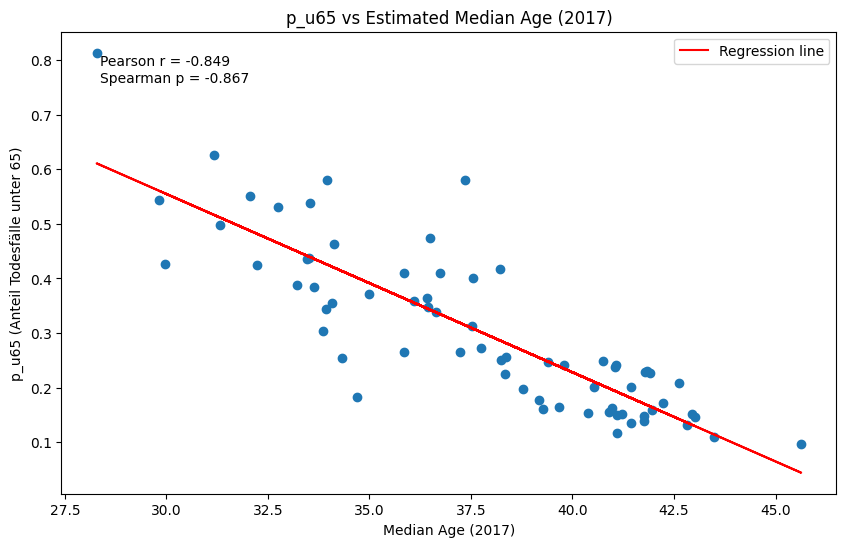

In [65]:

#Daten vorbereiten
scatter_data_u65 = df_2017_clean.merge(age_all,on="Country",how="inner")
scatter_data_u65 = scatter_data_u65.dropna(subset=["median_age_proxy", "p_u65"])

x = scatter_data_u65["median_age_proxy"].values
y = scatter_data_u65["p_u65"].values
#Lineare Regression
slope, intercept = np.polyfit(x, y, 1)

#damit die Linie sauber aussieht, x ist sortiert und passende y Werte werden berechnet
x_line = np.sort(x)
y_line = slope * x_line + intercept
reg_line = slope * x + intercept

#Pearson und Spearman berechnen
pearson_r, pearson_p = pearsonr(x, y)
spearman_r, spearman_p = spearmanr(x, y)

#Plot zeichnen
plt.figure(figsize=(10, 6))
plt.scatter(x, y)
plt.plot(x, reg_line, color="red", label="Regression line")
plt.xlabel("Median Age (2017)")
plt.ylabel("p_u65 (Anteil Todesfälle unter 65)")
plt.title("p_u65 vs Estimated Median Age (2017)")

#Pearson und Spearman Werte in den Plot schreiben
text = (f"Pearson r = {pearson_r:.3f}\n" f"Spearman p = {spearman_r:.3f}")
plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, fontsize=10, va="top")
plt.legend()
plt.show()


Der Scatterplot zeigt einen starken negativen Zusammenhang zwischen dem geschätzten Medianalter eines Landes und dem Anteil der Todesfälle unter 65 Jahren.
Der Pearson Wert (r 0 -0.85) zeigt, dass es einen linearen Zusammenhang gibt. Dies sieht man auch sehr gut durch die eingezeichnete Regressionsgerade. Auch der Spearman Koeffizient (p = −0.87) zeigt, dass der Zusammenhang auch insgesamt monoton fallend ist. Länder mit höherem Medianalter weisen einen geringeren Anteil an Todesfällen unter 65 Jahren auf.

### Zusammenhang zwischen Lebenserwartung und vorzeitiger Mortalität

               Country     p_u65  LifeExpectancy
0  Antigua and Barbuda  0.364121       77.030000
1            Argentina  0.264715       76.543000
2              Armenia  0.265843       75.217073
3                Aruba  0.250000       75.620000
4            Australia  0.178107       82.500000


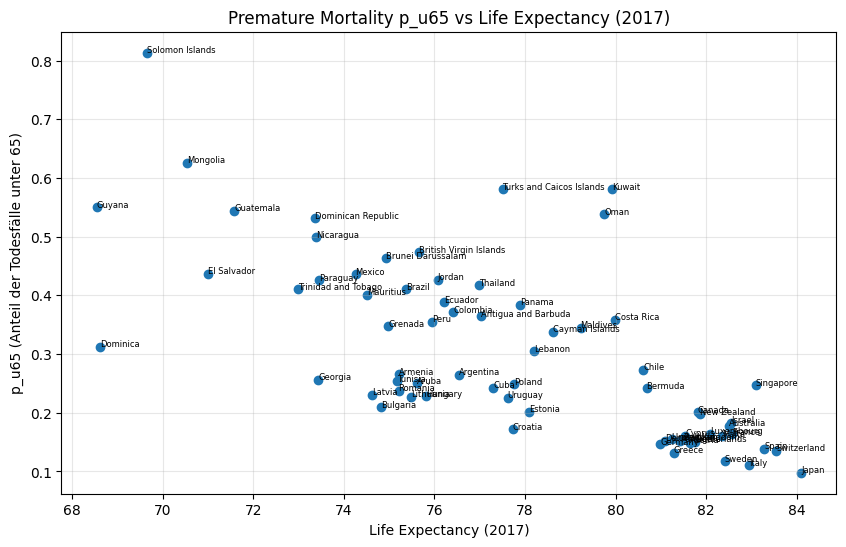

Pearson r (Life Expectancy vs p_u65): -0.701, p-value: 0.00000


In [71]:
#Life Expectancy Daten der World Bank einlesen
life_raw = pd.read_csv("Data_Files/API_SP.DYN.LE00.IN_DS2_en_csv_v2_309535.csv", skiprows=4)

#Nur Ländername und 2017 behalten
life_2017 = life_raw[["Country Name", "2017"]].rename(columns={"Country Name": "Country","2017": "LifeExpectancy"})

#Merge mit p_u65
corr_life = df_2017_clean.merge(life_2017, on="Country", how="inner")
corr_life = corr_life.dropna(subset=["LifeExpectancy"])

#Kontrolle
print(corr_life[["Country", "p_u65", "LifeExpectancy"]].head())

# Scatterplot
plt.figure(figsize=(10, 6))
plt.scatter(corr_life["LifeExpectancy"], corr_life["p_u65"])
plt.xlabel("Life Expectancy (2017)")
plt.ylabel("p_u65 (Anteil der Todesfälle unter 65)")
plt.title("Premature Mortality p_u65 vs Life Expectancy (2017)")
plt.grid(alpha=0.3)

for row in corr_life.itertuples():
    plt.text(row.LifeExpectancy, row.p_u65, row.Country, fontsize=6)
plt.show()

#Pearson-Korrelation
r_life, p_life = pearsonr(corr_life["LifeExpectancy"], corr_life["p_u65"])
print(f"Pearson r (Life Expectancy vs p_u65): {r_life:.3f}, p-value: {p_life:.5f}")


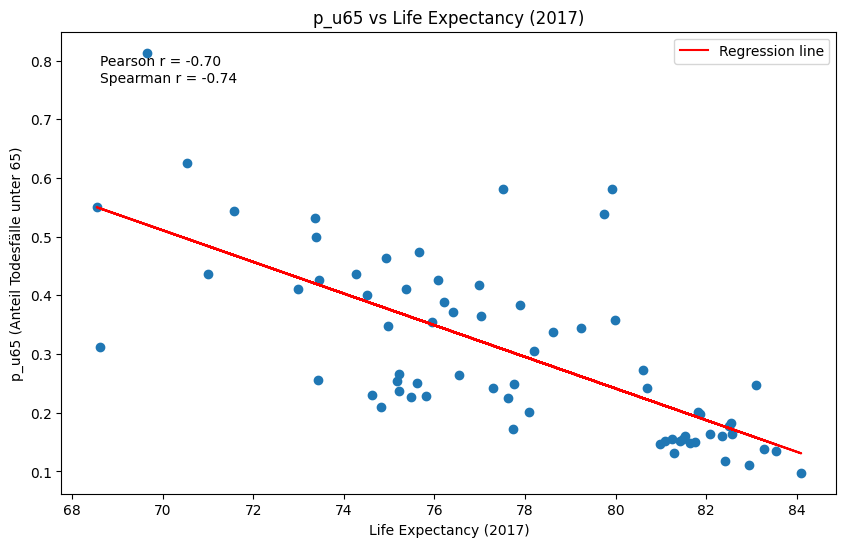

In [75]:
x = corr_life["LifeExpectancy"].values
y = corr_life["p_u65"].values

#lineare Regression
slope, intercept = np.polyfit(x, y, 1)

#damit die Linie sauber aussieht, x ist sortiert und passende y Werte werden berechnet
x_line = np.sort(x)
y_line = slope * x_line + intercept
reg_line = slope * x + intercept

#Pearson und Spearman
pearson_r, pearson_p = pearsonr(x, y)
spearman_r, spearman_p = spearmanr(x, y)

#Plot
plt.figure(figsize=(10, 6))
plt.scatter(x, y)
plt.plot(x, reg_line, color="red", label="Regression line")
plt.xlabel("Life Expectancy (2017)")
plt.ylabel("p_u65 (Anteil Todesfälle unter 65)")
plt.title("p_u65 vs Life Expectancy (2017)")

#Text im Plot anzeigen
text = f"Pearson r = {pearson_r:.2f}\nSpearman r = {spearman_r:.2f}"
plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, va="top")
plt.legend()
plt.show()


Der Scatterplot zeigt einen negativen Zusammenhang zwischen der Lebenserwartung eines Landes und dem Anteil der Todesfälle unter 65 Jahren.
Der Pearson Koeffizient (r = −0.70) zeigt einen deutlichen linearen Zusammenhang. Auch Spearman (p = −0.74) bestätigt diesen Trend. Die eingezeichnete Regressionsgerade verdeutlicht, dass Länder mit höherer Lebenserwartung einen geringeren Anteil an vorzeitiger Mortalität aufweisen. Wichtig ist, dass man nicht auf Kausalität schliessen darf.


## Hypothesentests
Nullhypothese H₀:

Der mittlere Anteil früher Todesfälle p_u65 ist in Ländern mit niedriger und hoher Lebenserwartung gleich.

Alternativhypothese H₁:

Länder mit niedriger Lebenserwartung haben einen höheren p_u65 als Länder mit hoher Lebenserwartung.

In [ ]:
#Median der Lebenserwartung berechnen
median_LE = corr_life["LifeExpectancy"].median()

#Länder in zwei Gruppen teilen
group_low = corr_life[corr_life["LifeExpectancy"] < median_LE]["p_u65"]
group_high = corr_life[corr_life["LifeExpectancy"] >= median_LE]["p_u65"]

#Gruppengrössen und Mittelwerte berechnen
print("n_low:", len(group_low))
print("n_high:", len(group_high))
print("mean_low:", group_low.mean())
print("mean_high:", group_high.mean())


n_low: 34
n_high: 35
mean_low: 0.38976393423982986
mean_high: 0.21874884972082762


Die Länder wurden anhand des Medians der Lebenserwartung in zwei Gruppen eingeteilt. Dadurch können wir nun untersuchen ob sich die beiden Gruppen der frühzeitigen Mortalität unterscheiden.

#### Gruppenvergleich

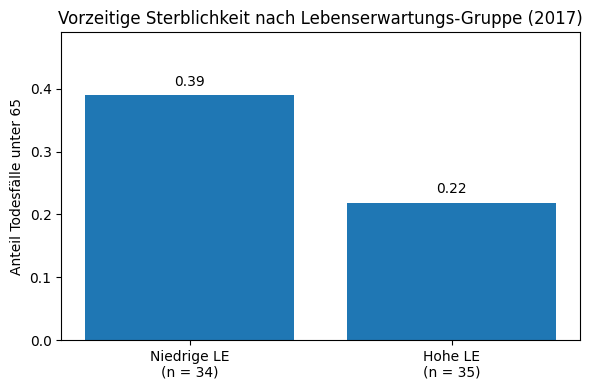

In [ ]:
#Mittelwerte und Gruppengrössen speichnern
means = [group_low.mean(), group_high.mean()]
ns    = [len(group_low), len(group_high)]

#Balkendiagramm labels
labels = [f"Niedrige LE\n(n = {ns[0]})", f"Hohe LE\n(n = {ns[1]})"]

#Balkendiagramm zeichnen
plt.figure(figsize=(6,4))
bars = plt.bar([0,1], means, tick_label=labels)

#Mittelwerte über den Balken anzeigen
for bar, mean in zip(bars, means):
    plt.text(bar.get_x() + bar.get_width() / 2,mean + 0.01,f"{mean:.2f}",ha="center",va="bottom",fontsize=10)

plt.ylabel("Anteil Todesfälle unter 65")
plt.title("Vorzeitige Sterblichkeit nach Lebenserwartungs-Gruppe (2017)")
plt.ylim(0, max(means) + 0.1)
plt.tight_layout()
plt.show()


Länder mit niedriger Lebenserwartung weisen mit 39% im Durchschnitt einen deutlich höheren Anteil an vorzeitigen Todesfällen auf als Länder mit hoher Lebenserwartung, welche 22% frühzeitige Todesfälle haben.

#### T-Test

In [ ]:
t_stat, p_val = ttest_ind(group_low, group_high, equal_var=False)

print("t-Wert:", t_stat)
print("p-Wert:", p_val)

t-Wert: 5.636228504318102
p-Wert: 4.2468807421222625e-07


Zum überprüfen, ob sich der durchschnittliche Anteil der Todesfälle unter 65 Jahren zwischen Ländern mit niedriger und hoher Lebenserwartung signifikant unterscheidet,
haben wir ein t-Test durchgeführt. Der Test ergab einen t-Wert von 5.64 und einen sehr kleinen p-Wert. Damit wird die Nullhypothese klar verworfen. Der Unterschied in der vorzeitigen Sterblichkeit zwischen den beiden Gruppen ist statistisch hochsignifikant.

#### Cohen's d

In [83]:
def cohens_d(x, y):
    #Anzahl Beobachtungen pro Gruppe
    n_x = len(x)
    n_y = len(y)
    #Mittelwerte der beiden Gruppen
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    #Standardabweichungen der Gruppen
    std_x= np.std(x, ddof=1)
    std_y= np.std(y, ddof=1)
    #Gepoolte Standardabweichung
    pooled_standart = np.sqrt(((n_x - 1) * std_x**2 + (n_y - 1) * std_y**2) / (n_x + n_y - 2))
    #Cohen's d berechnen
    d = (mean_x - mean_y) / pooled_standart
    return d
#Effektstärke berechnen
d = cohens_d(group_low, group_high)
print("Cohen's d:", d)


Cohen's d: 1.3611548118711552


Der bCohen's d Wert zeigt, dass sich der Anteil der Todesfälle unter 65 Jahren zwischen Ländern mit niedriger und hoher Lebenserwartung nicht nur statistisch
signifikant, sondern auch inhaltlich deutlich unterscheidet.

#### Permutationstest

In [ ]:
#p_u65 Werte der beiden Gruppen
A = group_low.values
B = group_high.values
#Alle Werte zusammenführen
data = np.concatenate([A, B])
#Grösse der ersten Gruppe
nA = len(A)

#tatsächlicher Unterschied der Mittelwerte
obs = A.mean() - B.mean()

diffs = []
for i in range(5000):
    #Werte zufällig mischen
    np.random.shuffle(data)
    
    #neue zufällige Gruppen bilden
    perm_A = data[:nA]
    perm_B = data[nA:]
    #Mittelwertsunterschied speichern
    diffs.append(perm_A.mean() - perm_B.mean())
diffs = np.array(diffs)

#zählen wie oft der zufällige Unterschied mindestens so extrem ist wie der beobachtete
extreme = np.sum(np.abs(diffs) >= abs(obs))
#p-Wert mit +1 Korrektur
p = (extreme + 1) / (len(diffs) + 1)

print("extreme Fälle:", extreme)
print("Permutation p-Wert:", p)



extreme Fälle: 0
Permutation p-Wert: 0.0001999600079984003


wir haben ein Permutationstest mit 5000 Zufallspermutationen durchgeführt. Dabei trat kein zufälliger Mittelwertsunterschied auf, der midnestens so extram war wie der beobachtete. Der p-Wert 0.0002 ist sehr klein, sodass die Nullhypothese klar verworfen wird. 

Beobachtete Δ: 0.17101508451900224
Permutation p-Wert: 0.0001999600079984003


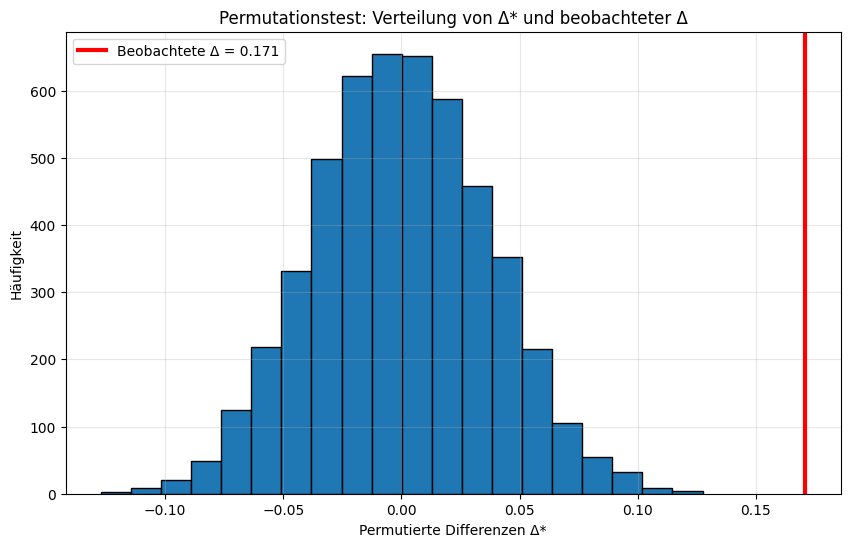

In [91]:
#Gruppen
A = group_low.values
B = group_high.values

#alle Daten zusammenführen
data = np.concatenate([A, B])
#Grösse der Gruppe A
nA = len(A)

#beobachtete Differenz
obs_diff = A.mean() - B.mean()
print("Beobachtete Δ:", obs_diff)

#Permutationstest
n_perm = 5000
perm_diffs = []
for i in range(5000):
    #Werte zufällig mischen
    np.random.shuffle(data)
    #neue zufällige Gruppen bilden
    perm_A = data[:nA]
    perm_B = data[nA:]
    #Mittelwertsunterschied speichern
    perm_diffs.append(perm_A.mean() - perm_B.mean())
perm_diffs = np.array(diffs)

# zweiseitiger p-Wert
extreme = np.sum(np.abs(perm_diffs) >= abs(obs_diff))
#+1 Korrektur
p = (extreme + 1) / (len(perm_diffs) + 1)
print("Permutation p-Wert:", p)

#plotten
plt.figure(figsize=(10, 6))

#Histogramm der permutierten Unterschiede
plt.hist(perm_diffs, bins=20, edgecolor="black")

#beobachtete Differenz rote Linie
plt.axvline(obs_diff, color="red", linewidth=3, label=f"Beobachtete Δ = {obs_diff:.3f}")

plt.xlabel("Permutierte Differenzen Δ*")
plt.ylabel("Häufigkeit")
plt.title("Permutationstest: Verteilung von Δ* und beobachteter Δ")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



Die Abbildung zeigt die Verteilung der permutierten Mittelwertsdifferenzen unter der Nullhypothese, dass kein Unterschied zwischen den beiden Gruppen besteht.
Die rote vertikale Linie markiert den beobachteten Mittelwertsunterschied. Der beobachtete Wert liegt weit ausserhalb der Permutationsverteilung.

## Kruskal-Wallis Test zwischen den Kontinenten (Euorpa, Südamerika und Nordamerika)

Nullhypothese: Die Verteilungen des Anteils der Todesfälle unter 65 Jahren (p_u65) sind in Europa, Nordamerika und Südamerika gleich. Es bestehen keine systematischen Unterschiede zwischen den Kontinenten.

H₁-Hypothese: Mindestens ein Kontinent weist eine unterschiedliche Verteilung von p_u65 auf. Es bestehen signifikante Unterschiede zwischen mindestens zwei Kontinenten.

Wir haben die Länder den drie Kontinenten Nordamerika, Südamerika und Europa zugeordnet. Dazu haben wir manuell Länderlisten für jeden Kontinent erstellt. Länder die keinem der drei Kontinenten zugoerdent werden konten haben wir gelöst.

In [ ]:
north_america = ["Canada", "United States of America", "Mexico", "Guatemala", "Belize", "Honduras", "El Salvador", "Nicaragua","Costa Rica", "Panama",
    "Cuba", "Haiti", "Dominican Republic", "Jamaica", "Trinidad and Tobago", "Bahamas", "Barbados"]

south_america = ["Brazil", "Argentina", "Chile", "Colombia", "Peru", "Bolivia","Ecuador", "Paraguay", "Uruguay", "Venezuela", "Guyana", "Suriname"]

europe = ["Germany", "France", "Italy", "Spain", "Portugal", "Switzerland", "Austria", "Belgium", "Netherlands", "Luxembourg", "United Kingdom",
    "Ireland", "Denmark", "Norway", "Sweden", "Finland", "Poland", "Czech Republic", "Slovakia", "Hungary", "Romania", "Bulgaria",
    "Greece", "Croatia", "Slovenia", "Serbia", "Bosnia and Herzegovina", "North Macedonia", "Albania", "Estonia", "Latvia", "Lithuania","Ukraine", "Moldova", "Iceland"]
def get_continent(country):
    if country in north_america:
        return "North America"
    elif country in south_america:
        return "South America"
    elif country in europe:
        return "Europe"
    else:
        return None

df_2017_clean["Continent"] = df_2017_clean["Country"].apply(get_continent)

df_3continents = df_2017_clean.dropna(subset=["Continent"])

<Figure size 1000x600 with 0 Axes>

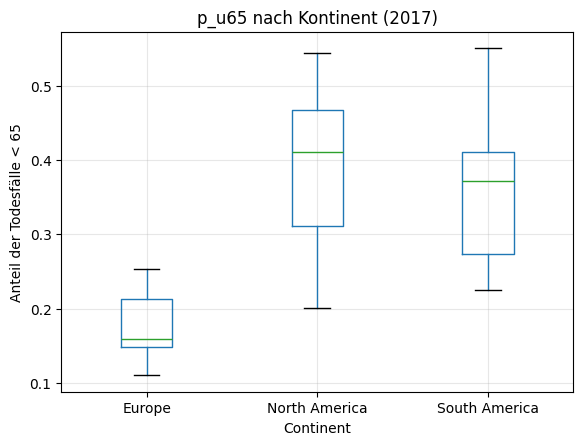

In [22]:
plt.figure(figsize=(10,6))
df_3continents.boxplot(column="p_u65", by="Continent")
plt.title("p_u65 nach Kontinent (2017)")
plt.suptitle("")
plt.ylabel("Anteil der Todesfälle < 65")
plt.grid(alpha=0.3)
plt.show()


Der Boxplot zeigt die Verteilung des Anteils der Todesfälle unter 65 Jahren für Europa, Nordamerika und Südamerika im Jahr 2017.

Europa weist insgesamt die niedrigsten p_u65-Werte auf und zeigt zudem eine vergleichsweise geringe Streuung. Nordamerika und Südamerika liegen deutlich höher, wobei Nordamerika den höchsten Median aufweist. Die größere Streuung in beiden amerikanischen Kontinenten deutet auf stärkere Unterschiede zwischen den einzelnen Ländern hin.

In [92]:
#Reihenfolge der Kontinente
continents = ["Europe", "North America", "South America"]

#Liste mit p_u65-Wert pro Kontinent
groups = []
for c in continents:
    values = df_3continents[df_3continents["Continent"] == c]["p_u65"].values
    groups.append(values)
#Kruskal-Wallis Test
H_stat, p_kruskal = kruskal(*groups)

print("Kruskal H:", H_stat)
print("Kruskal p-Wert:", p_kruskal)

Kruskal H: 27.959902050811166
Kruskal p-Wert: 8.483682609742949e-07


Der Test ergibt einen H-Wert von 27.96 und einen sehr kleinen p-Wert (p < 0.001). Damit wird die Nullhypothese verworfen, dass die Verteilungen von
p_u65 in allen drei Kontinenten gleich sind. Es bestehen somit statistisch hochsignifikante Unterschiede zwischen mindestens zwei der betrachteten Kontinente.

### Mann-Whitney-U-Tests

In [ ]:
#p_u65 Wert pro Kontinent
europe = df_3continents[df_3continents["Continent"] == "Europe"]["p_u65"].values
north_america = df_3continents[df_3continents["Continent"] == "North America"]["p_u65"].values
south_america = df_3continents[df_3continents["Continent"] == "South America"]["p_u65"].values

#Paarweise Mann-Whitney U Tests
tests = {"Europe vs North America": mannwhitneyu(europe, north_america, alternative="two-sided"),
         "Europe vs South America": mannwhitneyu(europe, south_america, alternative="two-sided"),
         "North America vs South America": mannwhitneyu(north_america, south_america, alternative="two-sided")}

for name, result in tests.items():
    print(name)
    print("U-Statistik:", result.statistic)
    print("p-Wert (unkorrigiert):", result.pvalue)
    print()


Europe vs North America
U-Statistik: 10.0
p-Wert (unkorrigiert): 1.5793903931199212e-05

Europe vs South America
U-Statistik: 6.0
p-Wert (unkorrigiert): 4.0801364013289785e-05

North America vs South America
U-Statistik: 59.0
p-Wert (unkorrigiert): 0.4941245444092638



Nach dem signifikanten Kruskal-Wallis-Test haben wir paarweise Mann-Whitney-U-Tests durchgeführt. Dadurch konnten wir sehen zwischen welchen Länder signifikante Unterschiede bestehen.

Europa vs. Nordamerika: Signifikanter Unterschied (p < 0.001)

Europa vs. Südamerika:Signifikanter Unterschied (p < 0.001)

Nordamerika vs. Südamerika: kein signifikanter Unterschied festgestellt -> p = 0.49

### FDR-Korrektur 

In [ ]:
#Unkorrigierte Werte aus den drei Tests
p_raw = np.array([tests["Europe vs North America"].pvalue, tests["Europe vs South America"].pvalue, tests["North America vs South America"].pvalue])

# FDR-Korrektur mit Benjamini-Hochberg
result = multipletests(p_raw, alpha=0.05, method="fdr_bh")
#True/False -> nach FDR signifikant
reject = result[0]
#korrigierte p-Werte
p_fdr  = result[1]

#Ergebnisse sauber ausgeben
comparisons = list(tests.keys())
for i in range(len(comparisons)):
    print(comparisons[i])
    print("p roh: ", p_raw[i])
    print("p FDR: ", p_fdr[i])
    print("Signifikant nach FDR:", reject[i])
    print()

Europe vs North America
p roh:  1.5793903931199212e-05
p FDR:  4.738171179359764e-05
Signifikant nach FDR: True

Europe vs South America
p roh:  4.0801364013289785e-05
p FDR:  6.120204601993468e-05
Signifikant nach FDR: True

North America vs South America
p roh:  0.4941245444092638
p FDR:  0.4941245444092638
Signifikant nach FDR: False



Nach der FDR-Korrektur sind die Unterschiede zwischen Europa und Nordamerika sowie zwischen Europa und Südamerika signifikant. Der Vergleich zwischen Nordamerika und Südamerika ist hingegen nicht signifikant.

## Lineare Regression: p_u65 und Lebenserwartung (2017)

In [95]:
#Nur Zeilen behalten wo beide Werte vorhanden sind p_u65 und LifeExpectancy
df_reg = corr_life.dropna(subset=["p_u65", "LifeExpectancy"]).copy()

X = df_reg["LifeExpectancy"]
Y = df_reg["p_u65"]

#Konstante hinzufügen Achsenabschnitt
X = sm.add_constant(X)

#Lineares Regressionsmodell berechnen
model = sm.OLS(Y, X).fit()
#Ergebnisse ausgeben
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  p_u65   R-squared:                       0.492
Model:                            OLS   Adj. R-squared:                  0.484
Method:                 Least Squares   F-statistic:                     64.85
Date:                Sun, 04 Jan 2026   Prob (F-statistic):           1.93e-11
Time:                        14:58:08   Log-Likelihood:                 56.140
No. Observations:                  69   AIC:                            -108.3
Df Residuals:                      67   BIC:                            -103.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              2.3980      0.260      9.

Das Modell ist statistisch hochsignifikant (F-Test p < 0.001) und erklärt 49 % der Varianz von p_u65. Der geschätzte Regressionskoeffizient der
Lebenserwartung ist -0.027. Das heisst, ein Anstieg der Lebenserwartung um ein Jahr ist mit einem Rückgang des Anteils der Todesfälle unter 65 Jahren um etwa 2.7% verbunden.

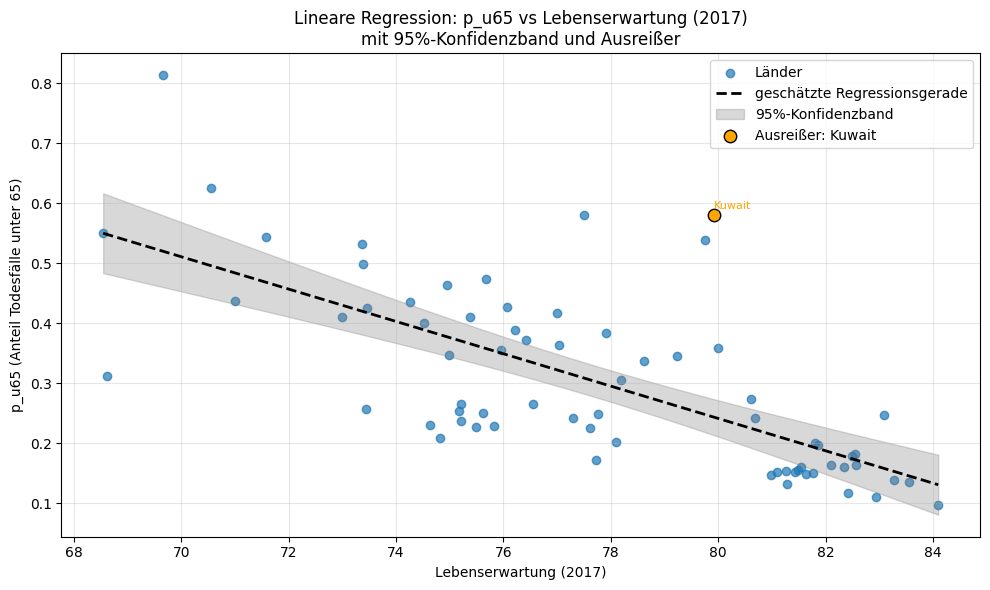

In [ ]:
#X-Werte (Lebenserwartung) gleichmässig über den Bereich verteilen
x_pred = np.linspace(df_reg["LifeExpectancy"].min(), df_reg["LifeExpectancy"].max(), 200)
#Konstante für Achsenabschnitt hinzufügen
X_pred = sm.add_constant(x_pred)

#Vorhersage mit 95% Konfidenzintervall 
pred = model.get_prediction(X_pred)
pred_ci = pred.summary_frame(alpha=0.05)

#geschätzte Mittelwerte (Regressionslinie)
y_pred   = pred_ci["mean"]
#untere Grenze Konfidenzintervall
ci_lower = pred_ci["mean_ci_lower"]
#untere Grenze Konfidenzintervall
ci_upper = pred_ci["mean_ci_upper"]

#Residuen = beobachtet - vorhergesagt
residuals = model.resid
#Index des Ausreissers mit dem grössten Residuum
idx_outlier = residuals.abs().idxmax()
#Datenzeile des Ausreissrs
row_out = df_reg.loc[idx_outlier]

#plot zeichnen
plt.figure(figsize=(10, 6))
#Punkte -> alle Länder
plt.scatter(df_reg["LifeExpectancy"], df_reg["p_u65"],color="tab:blue", alpha=0.7, label="Länder")

#Regressionsgerade
plt.plot(x_pred, y_pred, "k--", linewidth=2, label="geschätzte Regressionsgerade")

#95%-Konfidenzband
plt.fill_between(x_pred, ci_lower, ci_upper, color="grey", alpha=0.3,label="95%-Konfidenzband")

#Ausreisser markieren
plt.scatter(row_out["LifeExpectancy"], row_out["p_u65"], color="orange", edgecolor="black", s=80, label=f"Ausreißer: {row_out['Country']}")
#Ausreisser beschriften
plt.text(row_out["LifeExpectancy"], row_out["p_u65"] + 0.01, row_out["Country"], fontsize=8, color="orange")

plt.xlabel("Lebenserwartung (2017)")
plt.ylabel("p_u65 (Anteil Todesfälle unter 65)")
plt.title("Lineare Regression: p_u65 vs Lebenserwartung (2017)\n""mit 95%-Konfidenzband und Ausreißer")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Die gestrichelte Linie ist die geschätzte lineare Regressionsgerade. Das graue Band das 95%-Konfidenzintervall.
Es zeigt sich ein klar negativer Zusammenhang. Länder mit höherer Lebenserwartung weisen im Durchschnitt einen geringeren Anteil vorzeitiger Todesfälle auf.
Kuwait fällt als Ausreißer auf, da der beobachtete p_u65-Wert über dem erwarten liegt. Solche Ausreißer können auf besondere strukturelle, medizinische oder demografische Faktoren hinweisen.

#### Residuenplot

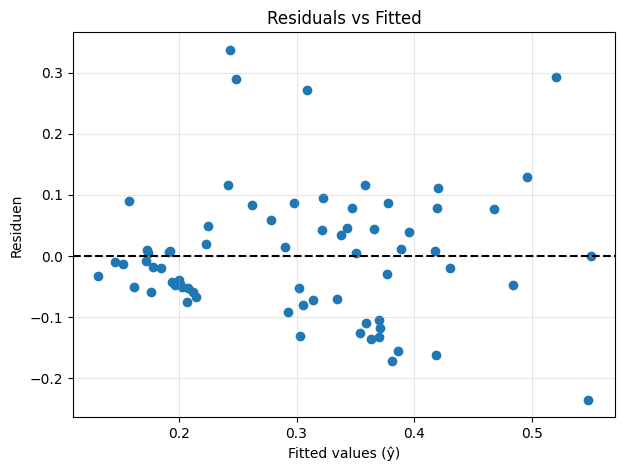

In [ ]:
#Residuen berechnen
residuals = model.resid
fitted = model.fittedvalues

plt.figure(figsize=(7,5))
plt.scatter(fitted, residuals)
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuen")
plt.title("Residuals vs Fitted")
plt.grid(alpha=0.3)
plt.show()


Der Residuenplot zeigt die Abweichungen zwischen beobachteten und vorhergesagten Werten in Abhängigkeit von den geschätzten Werten. Die Residuen streuen größtenteils zufällig um die Nulllinie, was die Annahme der Linearität unterstützt. Es ist keine klare Struktur zu erkennben. Allerdings treten bei höheren vorhergesagten Werten etwas grössere Streuungen. Insgesamt deutet der Plot aber darauf hin, dass lineare Regression geignet ist.

#### QQ-Plot der Residuen

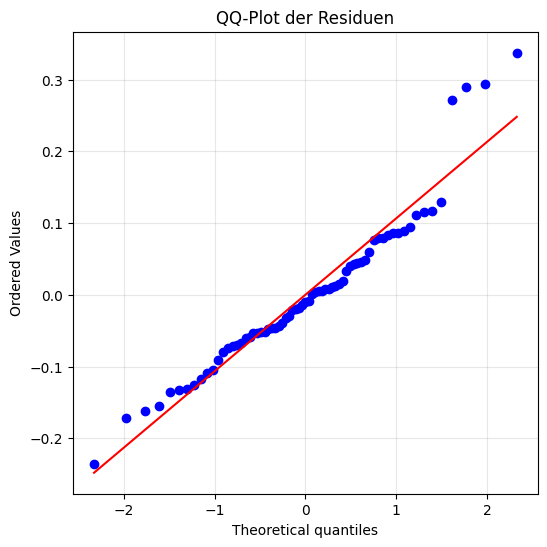

In [ ]:
plt.figure(figsize=(6,6))
stats.probplot(residuals, plot=plt)
plt.title("QQ-Plot der Residuen")
plt.grid(alpha=0.3)
plt.show()

Der QQ-Plot vergleicht die Verteilung der Residuen mit der Normalverteilung. Die Punkte liegen grösstenteils nahe an der Diagonalen, die Normalverteilung der Residuen ist daher erfüllt. An den Randbereichen sind leichte Abweichungen erkennbar, was auf Ausreisser und leichte Schiefe hindeutet.

#### Cook's Distance

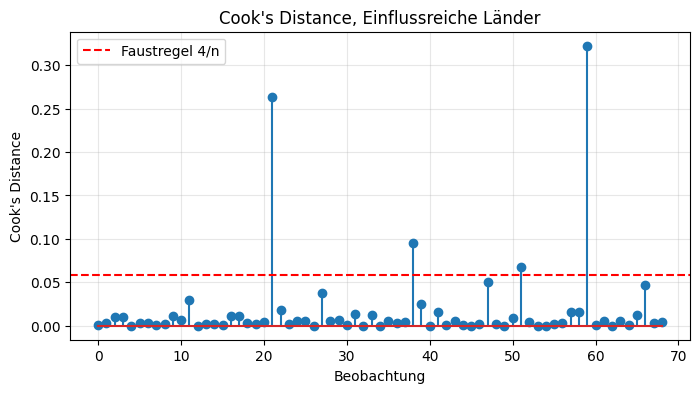

,Country,Year,deaths_u65_total,deaths_all_total,p_u65,tukey_flag,Continent,LifeExpectancy,cooks_d
59,Solomon Islands,2017,680.0,836,0.813397,high_outlier,None,69.652000,0.322455
21,Dominica,2017,376.0,1202,0.312812,ok,None,68.620000,0.262993
38,Kuwait,2017,7760.0,13358,0.580925,ok,None,79.916073,0.095327
51,Oman,2017,9132.0,16966,0.538253,ok,None,79.748000,0.067933
47,Mongolia,2017,19788.0,31624,0.625727,ok,None,70.543415,0.050861


In [101]:
#Einluss-Masse azs dem Regressionsmodell
influence = model.get_influence()
#Cook's Distance für alle Beobachtungen
cooks = influence.cooks_distance[0]
#plot
plt.figure(figsize=(8,4))
plt.stem(cooks) 
plt.axhline(4/len(cooks), color="red", linestyle="--", label="Faustregel 4/n")
plt.xlabel("Beobachtung")
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance, Einflussreiche Länder")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Top 5 einflussreichste Länder
df_cook = df_reg.copy()
df_cook["cooks_d"] = cooks
df_cook.sort_values("cooks_d", ascending=False).head()


Wir messen hier, wie stark einzelne Beobachtungen das Regressionsmodell beeinflussen. Hohe Werte deuten darauf hin, dass ein Land einen unverhältnismässig großen Einfluss auf die Regressionsgerade hat. Die rote Linie ist Orientierung. Beobachtungen oberhalb dieser Grenze gelten als einflussreich. Die 5 einflussreichsten Länder wir ausgegeben.

## Multiple Lineare Regression

Für diese Analyse brauchten wir die BIP Daten pro Land. Diese fanden wir auf einer Seite der World Bank
https://data.worldbank.org/indicator/NY.GDP.PCAP.CD?end=2017&start=1960&utm

In [102]:
#Csv mit BIP pro Kopf einlesen
gdp = pd.read_csv("Data_Files/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_2518.csv", skiprows=4)
#Land und Wert für 2017 behalten
gdp_2017 = gdp[["Country Name", "2017"]].dropna()
#Spalten umbennenen
gdp_2017.columns = ["Country", "GDP_per_capita"]

print(gdp_2017.head())

                       Country  GDP_per_capita
0                        Aruba    28440.051964
1  Africa Eastern and Southern     1520.212231
2                  Afghanistan      525.469771
3   Africa Western and Central     1574.230560
4                       Angola     2437.259712


In [ ]:
#Zusammenführen über den Ländernamen
df_merge = df_reg.merge(gdp_2017, on="Country", how="left")

#Kontrolle
print(df_merge.columns)
print(df_merge[["Country", "LifeExpectancy", "p_u65", "GDP_per_capita"]].head())

Index(['Country', 'Year', 'deaths_u65_total', 'deaths_all_total', 'p_u65',
       'tukey_flag', 'LifeExpectancy', 'GDP_per_capita'],
      dtype='object')
               Country  LifeExpectancy     p_u65  GDP_per_capita
0  Antigua and Barbuda       77.030000  0.364121    16965.728827
1            Argentina       76.543000  0.264715    14532.500931
2              Armenia       75.217073  0.265843     3869.053739
3                Aruba       75.620000  0.250000    28440.051964
4            Australia       82.500000  0.178107    53901.714539


In [103]:
# Zielvariable
Y = df_merge["p_u65"]
#Erklärende Variabeln: Lebenserwartung + Wohlstand
X = df_merge[["LifeExpectancy", "GDP_per_capita"]]
#Konstante für Achsenabschnitt hinzufügen
X = sm.add_constant(X)

model_multi = sm.OLS(Y, X, missing="drop").fit()
print(model_multi.summary())

                            OLS Regression Results                            
Dep. Variable:                  p_u65   R-squared:                       0.491
Model:                            OLS   Adj. R-squared:                  0.476
Method:                 Least Squares   F-statistic:                     31.39
Date:                Sun, 04 Jan 2026   Prob (F-statistic):           2.88e-10
Time:                        19:10:37   Log-Likelihood:                 55.443
No. Observations:                  68   AIC:                            -104.9
Df Residuals:                      65   BIC:                            -98.23
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              2.3335      0.336      6.

Lebenserwartung hat einen starken und signifikanten negativen Effekt p < 0.001
Steigt die Lebenserwartung um 1 Jahr, sinkt der Anteil der Todesfälle unter 65 um ca. 2.6 Prozentpunkte, bei konstantem BIP.
Das BIP pro Kopf** ist nicht signifikant p = 0.83.
Nach Kontrolle der Lebenserwartung erklärt Wohlstand keinen zusätzlichen Effekt auf p_u65.
-> Der Faktor des Wohlstandes ist bereits in der Lebenserwartung enthalten.

### 3D Regression

In [104]:
#Kopie der Daten erstellen
df_plot = df_merge.copy()

#GDP pro Kopf in Tausend USD, besser für den Plot
df_plot["GDP_k"] = df_plot["GDP_per_capita"] / 1000

#Zielvariable
y = df_plot["p_u65"]

#Erklärende Variabeln: Lebenseerwartung und BIP in Tausend USD
X_plot = df_plot[["LifeExpectancy", "GDP_k"]]
#Konstante für Achsenabschnitt
X_plot = sm.add_constant(X_plot)

#Lineares Regressionsmodell
model_plot = sm.OLS(y, X_plot, missing="drop").fit()
print(model_plot.summary())

                            OLS Regression Results                            
Dep. Variable:                  p_u65   R-squared:                       0.491
Model:                            OLS   Adj. R-squared:                  0.476
Method:                 Least Squares   F-statistic:                     31.39
Date:                Sun, 04 Jan 2026   Prob (F-statistic):           2.88e-10
Time:                        19:20:36   Log-Likelihood:                 55.443
No. Observations:                  68   AIC:                            -104.9
Df Residuals:                      65   BIC:                            -98.23
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              2.3335      0.336      6.

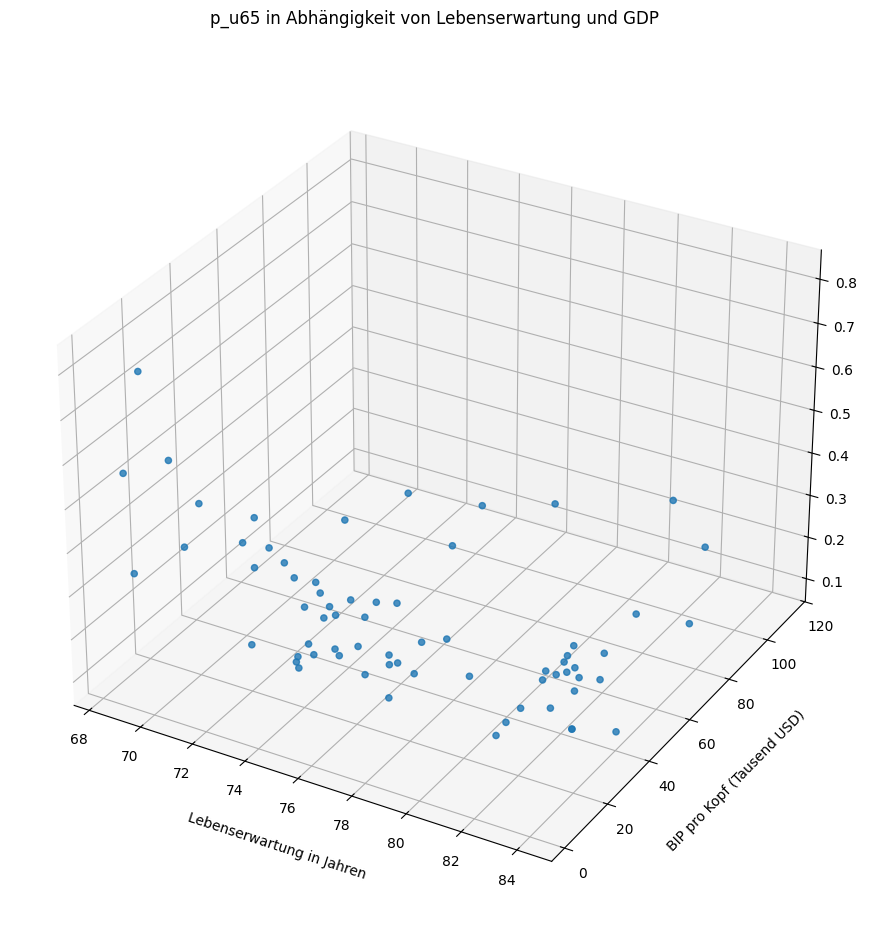

In [107]:
#x-Achse: Lebenserwartung
x_le = df_plot["LifeExpectancy"].values

#y-Achse: BIP pro Kopf in Tsd. USD
x_gdp = df_plot["GDP_k"].values

#z-Achse: Anteil Todesfälle unter 65
y = df_plot["p_u65"].values

#Gitter für Fläche
le_grid = np.linspace(x_le.min(), x_le.max(), 30)
gdp_grid = np.linspace(x_gdp.min(), x_gdp.max(), 30)
LE, GDP = np.meshgrid(le_grid, gdp_grid)

#Regressionsgleichung
Z = (model_plot.params["const"] + model_plot.params["LifeExpectancy"] * LE + model_plot.params["GDP_k"] * GDP)

#3D Plot erstellen
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection="3d")

#Punkte(Länder)
ax.scatter(x_le, x_gdp, y, alpha=0.8)

#Regressionsfläche
ax.plot_surface(LE, GDP, Z, alpha=0.3)

#Achsenbeschriftungen
ax.set_xlabel("Lebenserwartung in Jahren", labelpad=12)
ax.set_ylabel("BIP pro Kopf (Tausend USD)", labelpad=14)
ax.set_zlabel("nteil Todesfälle < 65", labelpad=10)

ax.set_title("p_u65 in Abhängigkeit von Lebenserwartung und GDP", pad=30)

#Layout
fig.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.9)

plt.show()

Jedes Land wird durch die Lebenserwartung (x-Achse), das BIP (y-Achse) und den Anteil der Todesfälle unter 65 Jahren (z-Achse) beschrieben.

Es ist ein klarer negativer Zusammenhang zwischen der Lebenserwartung und p_u65 erkennbar. Der Einfluss des GDP pro Kopf ist deutlich schwächer. Länder mit sehr unterschiedlichem Wohlstand können ähnliche p_u65-Werte haben.